In [1]:
import sys
sys.path.insert(0, "/staging/leuven/stg_00002/lcb/gpartel/software/deepSCENIC")

import torch
import numpy as np
import scanpy as sc
import pandas as pd
import argparse
import json

from src.deepSCENIC import deepSCENIC

/staging/leuven/stg_00002/lcb/gpartel/software/anaconda3/envs/DeepSEM/lib/python3.8/site-packages/requests/__init__.py:102: RequestsDependencyWarning: urllib3 (1.26.9) or chardet (5.1.0)/charset_normalizer (2.0.12) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({})/charset_normalizer ({}) doesn't match a supported "
2024-02-02 15:40:15.326521: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-02-02 15:40:15.478878: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=

In [2]:
# Compile deepSCENIC model
RES_PATH = '/lustre1/project/stg_00002/lcb/gpartel/projects/deepSCENIC/results/MM_lines_Enformer/'
parser = argparse.ArgumentParser()
opt = parser.parse_args('')
with open(RES_PATH + "/hyperparma.txt", 'r') as f:
            opt.__dict__.update(json.load(f))

opt.train = False
opt.use_best = True

if opt.use_best==True:
    model_dict_tf2r_func_enc_path = opt.load_model + 'best_model_tf2r_encoder.pth'
    model_dict_tf2r_path = opt.load_model + 'best_model_tf2r.pth'
    vae_model_path = opt.load_model + 'best_model.pth'
else:
    model_dict_tf2r_func_enc_path = opt.load_model + 'model_tf2r_encoder.pth'
    model_dict_tf2r_path = opt.load_model + 'model_tf2r.pth'
    vae_model_path = opt.load_model + 'model.pth'     
    
model = deepSCENIC(opt)            

dir exist


In [3]:
# Load SCENIC+ object

import dill
scplus_obj = dill.load(open('/lustre1/project/stg_00002/lcb/gpartel/projects/deepSCENIC/data/MM_lines/scplus_obj.pkl', 'rb'))

In [4]:
# Load orginal gene expression matrix and scaling it
original_matrix = sc.read(opt.data_rna_file).to_df()
original_matrix = original_matrix / original_matrix.std(0)

In [5]:
# Compute pca embedding
scplus_obj.dr_cell['tf_exp_PCA'] = pd.DataFrame(sc.pp.pca(original_matrix.values, n_comps=2), index=original_matrix.index, columns=['PC0', 'PC1'])

In [6]:
E1 = pd.read_pickle(RES_PATH + 'E1.pkl')
E2 = pd.read_pickle(RES_PATH + 'E2.pkl')
adj_E1 = torch.tensor(E1.values).to(opt.device)
adj_E2 = torch.tensor(E2.values).to(opt.device)

In [7]:
d = {
    'ZEB1':0,
    # 'SPIC':4.976473,
    # 'PRDM12':4.609183,
    # 'CEBPA':3.915442,
    # 'TIGD1':3.737906,
    # 'EP300':0,
    # 'KDM4A':0,
    # 'BCLAF1':0,
    # 'LYL1':0,
    # 'KDM5A':0,
}    

In [21]:
# Run perturbation simulation
n_iter = 5 # Perform 5 rounds of perturbation
perturbed_matrix, fcs = model.simulate_perturbation(
            vae_model_path=vae_model_path,
            tf2r_model_path = model_dict_tf2r_path,
            tf2r_func_enc_model_path = model_dict_tf2r_func_enc_path,
            perturbation=d, # knockdown TCF4
            adj_E1=adj_E1.T,
            adj_E2=adj_E2,
            n_iter=n_iter, 
            keep_intermediate=True,
            fc_upper_bound=99,
            fc_lower_bound=0)

reading data...
data read!
AnnData object with n_obs × n_vars = 936 × 12188
    var: 'n_cells'
    layers: 'log_norm'
AnnData object with n_obs × n_vars = 936 × 281820
         Falling back to preprocessing with `sc.pp.pca` and default params.


/staging/leuven/stg_00002/lcb/gpartel/software/deepSCENIC/src/deepSCENIC.py:402: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  perturbed_matrix.loc[:, gene] = perturbation[gene]
 20%|██        | 1/5 [00:04<00:17,  4.36s/it]/staging/leuven/stg_00002/lcb/gpartel/software/deepSCENIC/src/deepSCENIC.py:413: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  perturbed_matrix.loc[:, gene] = perturbation[gene]
 40%|████      | 2/5 [00:11<00:17,  5.70s/it]/staging/leuven/stg_00002/lcb/gpartel/software/deepSCENIC/src/deepSCENIC.py:413: FutureWarning: In a future ve

In [22]:
# Project perturbation in embedding
from scenicplus.simulation import _project_perturbation_in_embedding

reduction_name = 'tf_exp_PCA'
delta_embedding = _project_perturbation_in_embedding(
    scplus_obj = scplus_obj, 
    original_matrix = perturbed_matrix['0'].astype(np.double).copy(),
    perturbed_matrix = perturbed_matrix[str(n_iter+1)].astype(np.double).copy(), 
    reduction_name = 'tf_exp_PCA', 
    sigma_corr = 0.05, 
    n_cpu = 16)

/lustre1/project/stg_00002/lcb/gpartel/software/scenicplus/src/scenicplus/simulation.py:292: RuntimeWarning: invalid value encountered in divide
  unitary_vectors /= np.linalg.norm(unitary_vectors, ord=2, axis=0)  # divide by L2


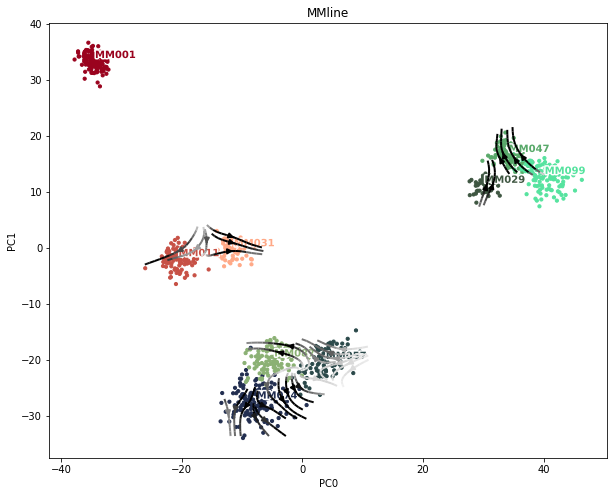

In [23]:
import matplotlib
import matplotlib.pyplot as plt
from scenicplus.dimensionality_reduction import plot_metadata_given_ax
from scenicplus.simulation import _calculate_grid_arrows
color_dict_line = {
    'MM001': '#9A031E',
    'MM011': '#C75146',
    'MM031': '#FFA987',
    'MM074': '#222E50',
    'MM087': '#8BB174',
    'MM057': '#2A4849',
    'MM029': '#3E5641',
    'MM047': '#59A96A',
    'MM099': '#56E39F'}
embedding = scplus_obj.dr_cell[reduction_name].to_numpy()
grid_xy, uv, mask = _calculate_grid_arrows(
    embedding=embedding, 
    delta_embedding=delta_embedding,
    offset_frac=0.005,
    n_grid_cols=25,
    n_grid_rows=25,
    n_neighbors=25,
    n_cpu=16)
distances = np.sqrt((uv**2).sum(1))
norm = matplotlib.colors.Normalize(vmin=0.15, vmax=0.5, clip=True)
scale = lambda X: [(x - min(X)) / (max(X) - min(X)) for x in X]
uv[np.logical_or(~mask, np.array(scale(distances)) < 0.15)] = np.nan
fig, ax = plt.subplots(figsize=(10, 8))
ax = plot_metadata_given_ax(
    scplus_obj=scplus_obj,
    reduction_name=reduction_name,
    ax = ax,
    variable = 'MMline',
    color_dictionary = {'MMline': color_dict_line},
    )
ax.streamplot(
        grid_xy.reshape(25,25, 2)[:, :, 0],
        grid_xy.reshape(25,25, 2)[:, :, 1],
        uv.reshape(25,25, 2)[:, :, 0],
        uv.reshape(25,25, 2)[:, :, 1], 
        density = 3, 
        color = np.array(scale(distances)).reshape(25, 25),
        cmap = 'Greys', 
        zorder = 10, 
        norm = norm,
        linewidth = 2)


In [12]:
# Load gene expression data
ad = sc.read(opt.data_rna_file)
cells_metadata = pd.read_csv('/lustre1/project/stg_00002/lcb/gpartel/projects/deepSCENIC/data/MM_lines/cells_metadata.csv', index_col=0)
ad.obs[cells_metadata.columns] = cells_metadata.loc[ad.obs.index,:].values
ad

AnnData object with n_obs × n_vars = 936 × 12188
    obs: 'MMline', 'lineState'
    var: 'n_cells'
    layers: 'log_norm'

In [13]:
# Compute fold change for each gene
fc = np.log2((perturbed_matrix[str(n_iter+1)]+1e-8)/(perturbed_matrix['0'] +1e-8))

# Average fold change per cell line
fc_line = []
for line in ad.obs.MMline.unique():
    fc_line.append(fc[ad.obs.MMline==line].mean(0))
fc_line = pd.DataFrame(fc_line, index=ad.obs.MMline.unique(), columns=perturbed_matrix['0'].columns)

# Drop perturbed genes
fc_line = fc_line.drop(['TCF4'], axis=1)

[[<matplotlib.axis.YTick at 0x14fbd1fd1850>,
 [Text(1, 5798.5, 'MITF'), Text(1, 10363.5, 'NLRC5')]]

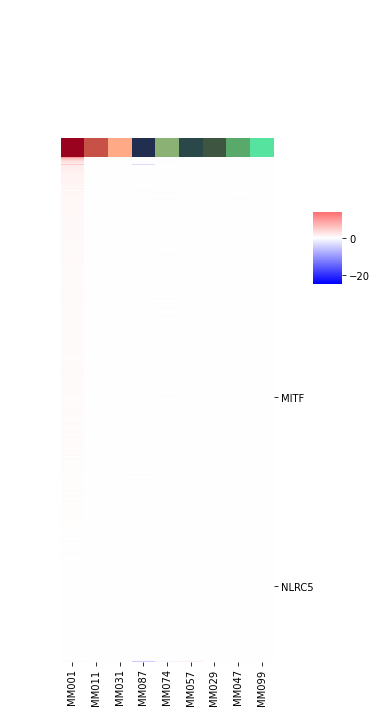

In [14]:
# Plot fc of each gene per cell line
import seaborn as sns
color_dict_line = {
    'MM001': '#9A031E',
    'MM011': '#C75146',
    'MM031': '#FFA987',
    'MM074': '#222E50',
    'MM087': '#8BB174',
    'MM057': '#2A4849',
    'MM029': '#3E5641',
    'MM047': '#59A96A',
    'MM099': '#56E39F'}


col_colors = list(color_dict_line.values())
sample_names = ['MITF', 'SOX10', 'NLRC5']

fc_line = fc_line.loc[['MM001', 'MM011', 'MM031', 'MM087', 'MM074', 'MM057', 'MM029', 'MM047', 'MM099'],fc_line.mean().sort_values(ascending=False).index].T

g = sns.clustermap(fc_line, col_colors=col_colors, row_cluster=False, col_cluster=False,figsize=(4,10), 
               yticklabels=False, method='average', cbar_pos=(1.1, 0.6, .1, .1), center =0, cmap='bwr')#, metric='correlation')

reordered_labels = fc_line.index.tolist()
use_labels = ['MITF','NLRC5']
use_ticks = [reordered_labels.index(label) + .5 for label in use_labels]

g.ax_heatmap.set(yticks=use_ticks, yticklabels=use_labels)

In [65]:
fc_line.max(1).sort_values()

SPANXC     0.000000
DOCK5      0.000000
PASD1      0.000000
SLC28A3    0.000000
RAD9B      0.000000
             ...   
RAB38      0.122335
GPNMB      0.132049
SYNGR1     0.148391
IQCE       0.151924
MLANA      0.159791
Length: 12199, dtype: float64

In [66]:
[fcs[str(n+2)].mean(0).max() for n in range(n_iter)]

[269914.7756612844,
 28043.694494913267,
 1.0054495365667961,
 1.001506127098361,
 129.97095170517105,
 1.0179377216471184,
 1.003781002390526,
 1.001943262221168,
 1.0011261564791771,
 1.0007670268537605,
 1.000552890296308,
 1.000438427569072,
 1.0003095738708476,
 1.0002336808250671,
 1.0001627358729799,
 1.0001367136362824,
 1.0001127962269103,
 1.0000841432056469,
 1.0000184633649112,
 1.0000615924574436,
 1.0000504906748848,
 1.0000021545076057,
 1.0000130810808254,
 1.0000096472827489,
 1.0000271645579746]

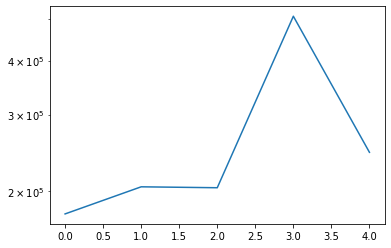

In [15]:
plt.plot([fcs[str(n+2)].mean(0).max() for n in range(n_iter)])
plt.yscale('log')